In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# DISCRETE-ADAM

In [3]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(c_value,)
    )

print(f"Final value of theta: {theta_history[-1]}")


Epoch: 50, theta=-1.475019e+00, Error: 4.988709e-04
Epoch: 100, theta=-1.450152e+00, Error: 4.955086e-04
Epoch: 150, theta=-1.425508e+00, Error: 4.900544e-04
Epoch: 200, theta=-1.401184e+00, Error: 4.827610e-04
Epoch: 250, theta=-1.377265e+00, Error: 4.739531e-04
Epoch: 300, theta=-1.353818e+00, Error: 4.639836e-04
Epoch: 350, theta=-1.330891e+00, Error: 4.531959e-04
Epoch: 400, theta=-1.308517e+00, Error: 4.418978e-04
Epoch: 450, theta=-1.286717e+00, Error: 4.303467e-04
Epoch: 500, theta=-1.265495e+00, Error: 4.187467e-04
Epoch: 550, theta=-1.244852e+00, Error: 4.072512e-04
Epoch: 600, theta=-1.224778e+00, Error: 3.959704e-04
Epoch: 650, theta=-1.205261e+00, Error: 3.849787e-04
Epoch: 700, theta=-1.186285e+00, Error: 3.743238e-04
Epoch: 750, theta=-1.167833e+00, Error: 3.640329e-04
Epoch: 800, theta=-1.149886e+00, Error: 3.541188e-04
Epoch: 850, theta=-1.132424e+00, Error: 3.445841e-04
Epoch: 900, theta=-1.115430e+00, Error: 3.354249e-04
Epoch: 950, theta=-1.098885e+00, Error: 3.26632

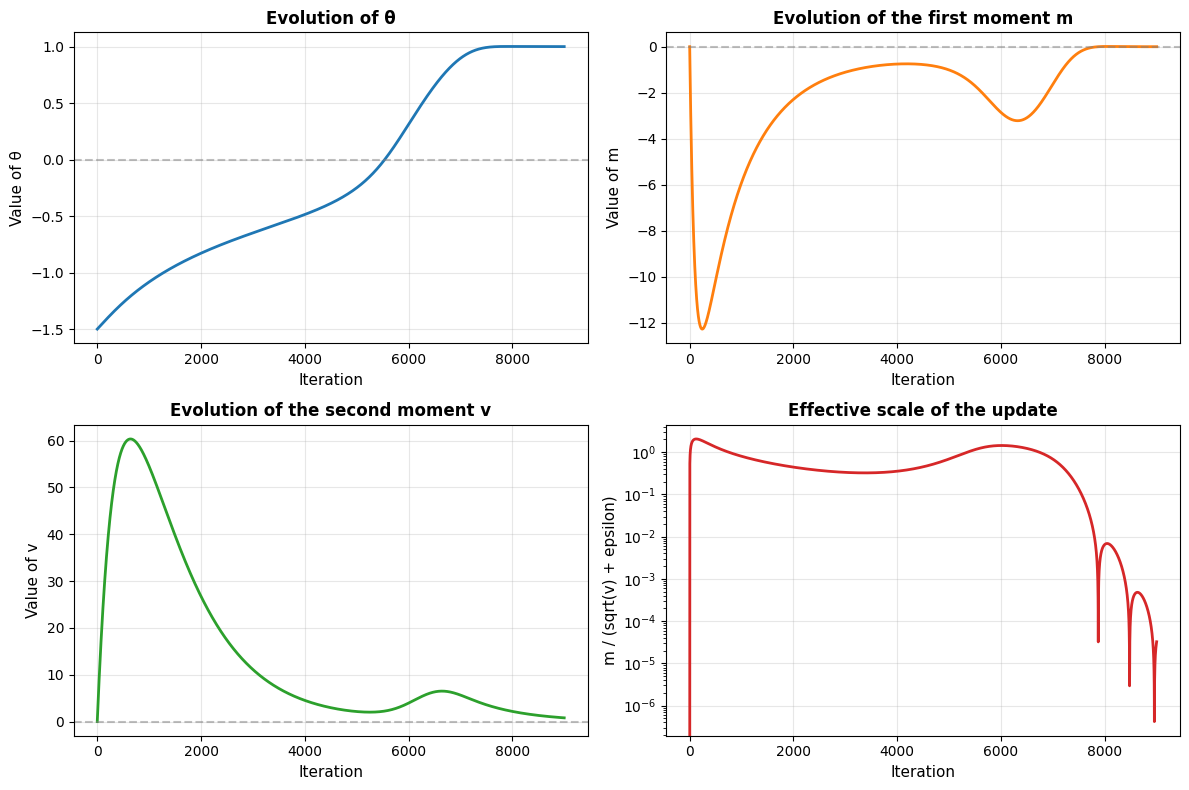

In [4]:
# Create Plotter and visualize
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plot all
plotter.plot('all')
plt.show()

## Save Results

In [5]:
# Create DataFrame
df_discrete = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': None,
    'theta_ddot_history': None,
    'm_history': m_history,
    'v_history': v_history
})

# Save to CSV
df_discrete.to_csv(f'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_discrete)}")

Results saved in 'results/c_1.5_results_initial_theta_-1.5_lr_0.0005_beta1_0.99_beta2_0.999.csv'
Total rows: 9000
